In [1]:
import os 
import matplotlib.pyplot as plt
import numpy as np
# 导入pytorch核心库，提供张量运算与GPU/CPU支持
import torch
# 导入神经网络模块，提供linea等层与损失函数
import torch.nn as nn
# 导入优化器模块
import torch.optim as optim
# 导入torchvision视觉工具包
import torchvision
# 导入图像变换、数据集、需训练模型
from torchvision import transforms, datasets, models
# 导入按文件夹组织的数据集类，文件夹名即为类别标签
from torchvision.datasets import ImageFolder
# 导入图像读写库
import imageio
# 导入时间模块，用于纪录训练时间
import time
import warnings
warnings.filterwarnings("ignore")
import copy
from PIL import Image
# 导入高级文件操作模块，用于复制图片到划分后的目录
import shutil
# 导入sklearn数据集随机划分函数
from sklearn.model_selection import train_test_split

数据分隔：训练集、测试集和验证集（8：1：1）

In [2]:
# 原始数据路径
data_dir = r'F:\药材识别\data'
# 目标路径（用于存放分割后的数据）
output_dir = r'F:\药材识别\split_data'
train_dir = os.path.join(output_dir, 'train')#划分后训练集数据
val_dir = os.path.join(output_dir, 'val')#划分后验证集数据
test_dir = os.path.join(output_dir, 'test')#划分后测试集数据
# 创建目标文件夹
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)
# 获取所有类别
categories = [cat for cat in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cat))]
# 遍历每个类别
for category in categories:
    # 获取该类别的所有图片路径
    cat_path = os.path.join(data_dir, category)
    images = [img for img in os.listdir(cat_path) if img.lower().endswith(('.png', '.jpg', '.jpeg', '.gif'))]
    # 第一次分割：80% 训练集，20% 剩余（用于测试和验证）
    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
    # 第二次分割：将剩余的 20% 分成 1:1（测试集和验证集各占原始数据的 10%）
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)
    # 创建类别子文件夹
    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(folder, category), exist_ok=True)
    # 复制图片到对应文件夹
    for img in train_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(train_dir, category, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(val_dir, category, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(test_dir, category, img))
    print(f'类别 {category}: 训练集 {len(train_imgs)} 张, 验证集 {len(val_imgs)} 张, 测试集 {len(test_imgs)} 张')
print('\n数据分割完成！')

类别 baihe: 训练集 144 张, 验证集 18 张, 测试集 18 张
类别 dangshen: 训练集 152 张, 验证集 19 张, 测试集 19 张
类别 gouqi: 训练集 148 张, 验证集 18 张, 测试集 19 张
类别 huaihua: 训练集 133 张, 验证集 17 张, 测试集 17 张
类别 jinyinhua: 训练集 144 张, 验证集 18 张, 测试集 18 张

数据分割完成！


数据增强

In [ ]:
data_transforms={
    # 训练集：224x224，增强数据增强
    'train':
    transforms.Compose([
        # 调整图片大小（注意：数值设置太大CPU易跑不起来）
        transforms.Resize([256, 256]),
        # 数据增强（随机旋转、裁剪、水平翻转、垂直翻转、颜色抖动、灰度化）
        # 随机旋转30度到-30度
        transforms.RandomRotation(30),
        # 随机裁剪并缩放到224*224，裁剪面积占80%*100%，宽高比为0.9：1.1
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        # 随机水平翻转（50%概率执行）
        transforms.RandomHorizontalFlip(p=0.5),
        # 随机垂直翻转（30%概率执行）
        transforms.RandomVerticalFlip(p=0.3),
        # 随机颜色抖动：调整亮度、对比度、饱和度、色调，模拟不同光照
        transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2, hue=0.1),
        # 转换为张量
        transforms.ToTensor(),
        # 标准化：像素值转换为0-1之间
        # 均值：[0.485, 0.456, 0.406]
        # 标准差：[0.229, 0.224, 0.225]
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    # 验证集：224x224，不需要做数据增强，只需要调整大小和标准化
    'val':
    transforms.Compose([
        transforms.Resize([256, 256]),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    # 测试集：224x224（与验证集相同，不需要数据增强）
    'test':
    transforms.Compose([
        transforms.Resize([256, 256]),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

In [ ]:
# 批次大小：调整为16以适配CPU
batch_size=16
# 创建数据集字典，应用数据增强
image_datasets={x:ImageFolder(os.path.join(output_dir,x),data_transforms[x]) for x in ['train','val','test']}
# 创建数据加载器字典（shuffle=True-每个批次打乱数据顺序）
data_loaders={x:torch.utils.data.DataLoader(image_datasets[x],batch_size=batch_size,shuffle=True) for x in ['train','val','test']}
# 计算数据集大小（训练集和验证集）
dataset_sizes={x:len(image_datasets[x]) for x in ['train','val']}
# 获取类名列表（训练集的类名）
class_names=image_datasets['train'].classes
print(f'训练集大小: {dataset_sizes["train"]}, 验证集大小: {dataset_sizes["val"]}')
print(f'类别: {class_names}')

训练集大小: 721, 验证集大小: 90
类别: ['baihe', 'dangshen', 'gouqi', 'huaihua', 'jinyinhua']


加载模型
使用预训练ResNet18
微调整个网络

In [5]:
model_name='resnet'
# 微调整个网络
feature_extract=False

In [6]:
# 是否用GPU训练
train_on_gpu=torch.cuda.is_available()
if not train_on_gpu:
    print('警告：没有可用的GPU，将使用CPU训练')
else:
    print('将使用GPU训练')
device=torch.device('cuda:0' if train_on_gpu else 'cpu')

警告：没有可用的GPU，将使用CPU训练


In [7]:
#冻结参数函数：控制网络参数是否参与梯度更新，实现特征提取/模型微调两种迁移学习模式切换
def set_parameter_requires_grad(model,feature_extract):
    # 是否提取特征（冻结主干）
    if feature_extract:
        # 遍历模型所有可学习参数
        for param in model.parameters():
            # 标记该参数不需要梯度，反向传播时不更新
            param.requires_grad=False

In [8]:
# 模型初始化函数
def initialize_model(model_name,feature_extract,num_classes,use_pretrained=True):
    """初始化模型"""
    # 加载resnet18结构以及预训练权重
    model_fit=models.resnet18(pretrained=use_pretrained)
    # 按策略冻结或解冻参数
    set_parameter_requires_grad(model_fit,feature_extract)
    #读取原全连接层输入维度
    num_ftrs=model_fit.fc.in_features
    # 将1000类输出层微调为5类新线性层
    model_fit.fc=nn.Linear(num_ftrs,num_classes)
    # 图形输入参数
    input_size=224
    return model_fit,input_size

In [9]:
model_fit,imput_size=initialize_model(model_name,feature_extract,5,use_pretrained=True)
# 使用GPU还是CPU
model_fit=model_fit.to(device)
# 保存模型
filename='resnet18_optimized.pth'
# 是否训练所有层
params_to_update=model_fit.parameters()
print('Params to learn:')
if feature_extract:
    params_to_update=[]
    for name,param in model_fit.named_parameters():
        if param.requires_grad:
            params_to_update.append(param)
            print('\t',name)
    print('Only the last layer is updated.')
else:
    for name,param in model_fit.named_parameters():
        if param.requires_grad:
            print('\t',name)
    print('All layers are updated.')

Params to learn:
	 conv1.weight
	 bn1.weight
	 bn1.bias
	 layer1.0.conv1.weight
	 layer1.0.bn1.weight
	 layer1.0.bn1.bias
	 layer1.0.conv2.weight
	 layer1.0.bn2.weight
	 layer1.0.bn2.bias
	 layer1.1.conv1.weight
	 layer1.1.bn1.weight
	 layer1.1.bn1.bias
	 layer1.1.conv2.weight
	 layer1.1.bn2.weight
	 layer1.1.bn2.bias
	 layer2.0.conv1.weight
	 layer2.0.bn1.weight
	 layer2.0.bn1.bias
	 layer2.0.conv2.weight
	 layer2.0.bn2.weight
	 layer2.0.bn2.bias
	 layer2.0.downsample.0.weight
	 layer2.0.downsample.1.weight
	 layer2.0.downsample.1.bias
	 layer2.1.conv1.weight
	 layer2.1.bn1.weight
	 layer2.1.bn1.bias
	 layer2.1.conv2.weight
	 layer2.1.bn2.weight
	 layer2.1.bn2.bias
	 layer3.0.conv1.weight
	 layer3.0.bn1.weight
	 layer3.0.bn1.bias
	 layer3.0.conv2.weight
	 layer3.0.bn2.weight
	 layer3.0.bn2.bias
	 layer3.0.downsample.0.weight
	 layer3.0.downsample.1.weight
	 layer3.0.downsample.1.bias
	 layer3.1.conv1.weight
	 layer3.1.bn1.weight
	 layer3.1.bn1.bias
	 layer3.1.conv2.weight
	 layer3.1.b

设置优化器 学习率调整为1e-4 添加权重衰减 使用余弦退火学习率调度器

In [10]:
# 优化器Adam，学习率设置为0.0001，权重衰减0.0001防止模型过拟合
optimizer_ft=torch.optim.Adam(params_to_update,lr=1e-4,weight_decay=1e-4)
# 余弦退火：30个epoch内学习率从初始值平滑下降至0.000006
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft,T_max=30,eta_min=1e-6)
# 多分类交叉熵损失
criterion=nn.CrossEntropyLoss()

训练模型 添加早停机制

In [11]:
# 训练模型
def train_model(model,data_loaders,criterion,optimizer_ft,scheduler,num_epochs=30,patience=10,filename='resnet18_optimized.pth'):
    # 纪录训练开始时间
    since=time.time()
    # 初始化最佳准确率
    best_acc=0.0
    # 确保模型在正确设备上
    model.to(device)
    # 每个epoch验证准确率
    val_acc_history=[]
    # 每个epoch测试准确率
    train_acc_history=[]
    # 每个epoch训练损失
    train_loss_history=[]
    # 每个epoch验证损失
    val_loss_history=[]
    # 纪录初始学习率
    LRs=[optimizer_ft.param_groups[0]['lr']]
    # 深拷贝当前权重作为初始最佳权重备份
    best_model_wts=copy.deepcopy(model.state_dict())
    # 早停计数器（验证集中未提升的连续epoch计数）
    no_improve_count=0
    # 早停触发信号
    early_stop=False

    for epoch in range(num_epochs):
        if early_stop:
            print('早停触发，提前结束训练')
            break
        print(f'Epoch {epoch}/{num_epochs-1}')
        print('-' * 10)
        # 训练和验证
        for phase in ['train','val']:
            if phase=='train':
                model.train()
            else:
                model.eval()
            running_loss=0.0
            running_corrects=0
            # 遍历数据
            for inputs,labels in data_loaders[phase]:
                inputs=inputs.to(device)
                labels=labels.to(device)
                # 清零
                optimizer_ft.zero_grad()
                # 前向传播：只训练的时候计算和更新梯度
                with torch.set_grad_enabled(phase=='train'):
                    outputs=model(inputs)
                    loss=criterion(outputs,labels)
                    _,preds=torch.max(outputs,1)
                    # 反向传播
                    if phase=='train':
                        loss.backward()
                        optimizer_ft.step()
                # 计算损失
                running_loss+=loss.item()*inputs.size(0)
                running_corrects+=torch.sum(preds==labels.data)
            # 平均损失和准确率
            epoch_loss=running_loss/len(data_loaders[phase].dataset)
            epoch_acc=running_corrects.double()/len(data_loaders[phase].dataset)
            #计算运行时间
            time_elapsed=time.time()-since
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            # 得到最好结果那次的模型
            if phase=='val':
                if epoch_acc>best_acc:
                    best_acc=epoch_acc
                    best_model_wts=copy.deepcopy(model.state_dict())
                    state={
                        'state_dict':model.state_dict(),
                        'best_acc':best_acc,
                        'optimizer_ft':optimizer_ft.state_dict(),
                    }
                    torch.save(state,filename)
                    no_improve_count=0
                    print(f'验证集准确率提升！保存模型到 {filename}')
                else:
                    no_improve_count+=1
                    if no_improve_count>=patience:
                        early_stop=True
                        print(f'连续 {patience} 个epoch验证集准确率未提升')
                val_acc_history.append(epoch_acc)
                val_loss_history.append(epoch_loss)
            else:
                train_acc_history.append(epoch_acc)
                train_loss_history.append(epoch_loss)
        
        # 更新学习率（只在训练阶段后）
        scheduler.step()
        current_lr=optimizer_ft.param_groups[0]['lr']
        print(f'Optimizer learning rate: {current_lr:.7f}')
        LRs.append(current_lr)
        print()

    time_elapsed=time.time()-since
    print(f'Training completed in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val acc: {best_acc:.4f}')
    
    # 训练完后用最好的一次当作模型最终的结果，用于后续测试
    model.load_state_dict(best_model_wts)
    return model,val_acc_history,val_loss_history,LRs,train_acc_history,train_loss_history

#开始训练

In [12]:
model_ft,val_acc_history,val_loss_history,LRs,train_acc_history,train_loss_history=train_model(model_fit,data_loaders,criterion,optimizer_ft,scheduler,num_epochs=30,patience=10,filename='resnet18_optimized.pth')

Epoch 0/29
----------
train Loss: 0.5879 Acc: 0.7906
val Loss: 0.3443 Acc: 0.8778
验证集准确率提升！保存模型到 resnet18_optimized.pth
Optimizer learning rate: 0.0000997

Epoch 1/29
----------
train Loss: 0.2214 Acc: 0.9362
val Loss: 0.2507 Acc: 0.9222
验证集准确率提升！保存模型到 resnet18_optimized.pth
Optimizer learning rate: 0.0000989

Epoch 2/29
----------
train Loss: 0.1385 Acc: 0.9598
val Loss: 0.2270 Acc: 0.9333
验证集准确率提升！保存模型到 resnet18_optimized.pth
Optimizer learning rate: 0.0000976

Epoch 3/29
----------
train Loss: 0.1445 Acc: 0.9570
val Loss: 0.1846 Acc: 0.9333
Optimizer learning rate: 0.0000957

Epoch 4/29
----------
train Loss: 0.1026 Acc: 0.9723
val Loss: 0.1415 Acc: 0.9444
验证集准确率提升！保存模型到 resnet18_optimized.pth
Optimizer learning rate: 0.0000934

Epoch 5/29
----------
train Loss: 0.1288 Acc: 0.9556
val Loss: 0.1066 Acc: 0.9556
验证集准确率提升！保存模型到 resnet18_optimized.pth
Optimizer learning rate: 0.0000905

Epoch 6/29
----------
train Loss: 0.0950 Acc: 0.9750
val Loss: 0.1160 Acc: 0.9667
验证集准确率提升！保存模型到 resne

#绘制训练曲线

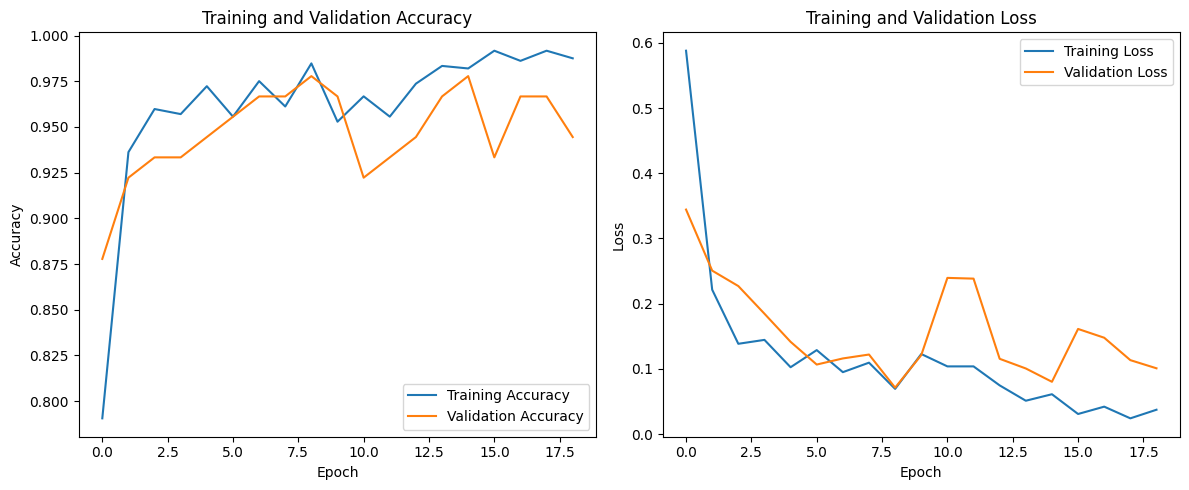

In [13]:
# 转换为numpy数组以便绘图
train_acc_np=[x.cpu().numpy() if torch.is_tensor(x) else x for x in train_acc_history]
val_acc_np=[x.cpu().numpy() if torch.is_tensor(x) else x for x in val_acc_history]

# 绘制准确率曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_np, label='Training Accuracy')
plt.plot(val_acc_np, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# 绘制损失曲线
plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()